In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import jenkspy
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import mean_squared_error as mse
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import os

In [2]:
county_fips = 48491
target = 'customers_out'

In [3]:
file_path = os.path.join('..','..', 'data', 'Merged_data', 'eaglei_noaa_era5_full.parquet')
df = pd.read_parquet(file_path)

In [4]:
df.head()

,,,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,event_count Heat,event_count Fire,event_count Wind,event_count Ocean,event_count Other,t2m,u10,v10,sf,tp
time,latitude,longitude,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,32.5,-86.6,1001.0,2.083333,2019-01-01 00:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,293.362183,0.961334,3.989058,0.0,0.003854
2019-01-01 06:00:00,32.5,-86.6,1001.0,0.000000,2019-01-01 06:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,292.707092,0.872604,2.616913,0.0,0.001672
2019-01-01 12:00:00,32.5,-86.6,1001.0,0.125000,2019-01-01 12:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,289.616882,0.323883,-2.613495,0.0,0.004106
2019-01-01 18:00:00,32.5,-86.6,1001.0,0.958333,2019-01-01 18:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,290.067749,0.286743,-0.936096,0.0,0.004162
2019-01-02 00:00:00,32.5,-86.6,1001.0,0.000000,2019-01-02 00:00:00,2019,Autauga,AL,0.079844,"[1051, 1085, 1101, 1047, 1021]",SRSO,-86.6,...,0.0,0.0,0.0,0.0,0.0,289.477539,0.208411,-1.321411,0.0,0.009568


In [5]:
df_county = df[(df['fips_code']==county_fips) & (df['datetime']<datetime.datetime(2021,1,1))]
del df
df_county

,,,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,event_count Heat,event_count Fire,event_count Wind,event_count Ocean,event_count Other,t2m,u10,v10,sf,tp
time,latitude,longitude,,,,,,,,,,,,,,,,,,,,,
2019-01-01 06:00:00,30.6,-97.6,48491.0,22.000000,2019-01-01 06:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,278.248108,2.121628,-0.349884,0.0,0.000000e+00
2019-01-01 12:00:00,30.6,-97.6,48491.0,1.333333,2019-01-01 12:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,277.208679,0.390289,-4.269745,0.0,0.000000e+00
2019-01-01 18:00:00,30.6,-97.6,48491.0,1.708333,2019-01-01 18:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,281.809937,-1.013062,-4.842346,0.0,0.000000e+00
2019-01-02 00:00:00,30.6,-97.6,48491.0,0.458333,2019-01-02 00:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,279.766602,-0.893151,-4.373169,0.0,0.000000e+00
2019-01-02 06:00:00,30.6,-97.6,48491.0,0.000000,2019-01-02 06:00:00,2019,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,278.664734,-0.297797,-4.211594,0.0,4.291534e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-29 12:00:00,30.6,-97.6,48491.0,1.166667,2014-12-29 12:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,273.047394,0.810837,2.074020,0.0,8.523463e-07
2014-12-29 18:00:00,30.6,-97.6,48491.0,0.625000,2014-12-29 18:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,285.300446,0.559097,2.732059,0.0,8.523463e-07
2014-12-30 00:00:00,30.6,-97.6,48491.0,0.000000,2014-12-30 00:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,...,0.0,0.0,0.0,0.0,0.0,285.253296,-1.209961,2.804070,0.0,8.523463e-07


In [6]:
df_county.columns

Index(['fips_code', 'customers_out', 'datetime', 'YEAR', 'NAME', 'STUSPS',
       'Pct_Buried_Lines', 'neighbors', 'Subregion', 'centroid_longitude',
       'centroid_latitude', 'centroid_rounded', 'POPULATION', 'BUILDVALUE',
       'AGRIVALUE', 'AREA', 'SOVI_SCORE', 'Power_Dependent_Devices_DME_Mean',
       'event_count SnowIce', 'event_count Flood', 'event_count Storm',
       'event_count Hurricane', 'event_count Heat', 'event_count Fire',
       'event_count Wind', 'event_count Ocean', 'event_count Other', 't2m',
       'u10', 'v10', 'sf', 'tp'],
      dtype='object')

In [7]:
df_county.drop('fips_code',axis=1, inplace=True)
df_county.sort_values(by='datetime',inplace=True)

In [8]:
df_county

,,,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,centroid_latitude,...,event_count Heat,event_count Fire,event_count Wind,event_count Ocean,event_count Other,t2m,u10,v10,sf,tp
time,latitude,longitude,,,,,,,,,,,,,,,,,,,,,
2014-11-01 00:00:00,30.6,-97.6,2.000000,2014-11-01 00:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,292.158691,-1.260422,-3.944397,0.0,0.000678
2014-11-01 06:00:00,30.6,-97.6,0.250000,2014-11-01 06:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,286.453857,-1.559616,-2.737137,0.0,0.000000
2014-11-01 12:00:00,30.6,-97.6,0.875000,2014-11-01 12:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,282.595703,-2.026154,-1.791412,0.0,0.000001
2014-11-01 18:00:00,30.6,-97.6,0.291667,2014-11-01 18:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,290.646484,-2.451431,0.991882,0.0,0.000001
2014-11-02 00:00:00,30.6,-97.6,0.125000,2014-11-02 00:00:00,2014,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,0.0,289.140137,-2.224731,1.599930,0.0,0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-30 00:00:00,30.6,-97.6,68.708333,2020-12-30 00:00:00,2020,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,1.0,292.665100,-2.441017,6.522034,0.0,0.000541
2020-12-30 06:00:00,30.6,-97.6,0.166667,2020-12-30 06:00:00,2020,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,1.0,291.128296,-1.617661,5.503357,0.0,0.000979
2020-12-30 12:00:00,30.6,-97.6,3.791667,2020-12-30 12:00:00,2020,Williamson,TX,0.27187,"[48053, 48287, 48453, 48331, 48021, 48027]",ERCT,-97.6,30.6,...,0.0,0.0,0.0,0.0,1.0,291.268951,-0.558884,5.031296,0.0,0.002414


In [10]:
features = df_county.columns[-16:-2].to_list()
features.append(target)
features

['event_count SnowIce',
 'event_count Flood',
 'event_count Storm',
 'event_count Hurricane',
 'event_count Heat',
 'event_count Fire',
 'event_count Wind',
 'event_count Ocean',
 'event_count Other',
 't2m',
 'u10',
 'v10',
 'sf',
 'tp',
 'customers_out']

In [11]:
df_county[features].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
event_count SnowIce,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Flood,8973.0,6.240945e-03,0.129150,0.000000,0.000000,0.000000,0.000000,5.000000
event_count Storm,8973.0,5.126491e-03,0.123012,0.000000,0.000000,0.000000,0.000000,8.000000
event_count Hurricane,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Heat,8973.0,2.006018e-03,0.044746,0.000000,0.000000,0.000000,0.000000,1.000000
event_count Fire,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Wind,8973.0,5.906609e-03,0.139536,0.000000,0.000000,0.000000,0.000000,6.000000
event_count Ocean,8973.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
event_count Other,8973.0,1.258219e-01,0.333677,0.000000,0.000000,0.000000,0.000000,2.000000
t2m,8973.0,2.934431e+02,8.504444,266.217468,287.387421,294.387939,299.423340,314.643311


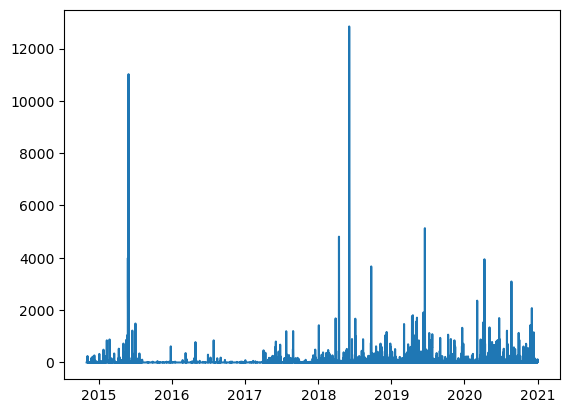

In [12]:
plt.plot(df_county['datetime'],df_county['customers_out'])

## Training using LSTM

In [13]:
WINDOW_SIZE = 20

In [14]:
def data_to_input_and_output(data,target,features):
    """
    Inputs:
    data - a timeseries in dataframe format, should be longer than WINDOW_SIZE
    target - a string with the name of the target feature
    features - a list with the names of all features used for training, should contain 'target'

    Returns:
    input_data - whose entries will be WINDOW_SIZE consecutive entries of data
    output_data - whose entries will be the element that follows after the WINDOW_SIZE consecutive elements

    For example if data = [0,1,2,3,4,5] and WINDOW_SIZE = 2 then
    input_data      output_data
    [[0,1],         [2,
    [1,2],           3,
    [2,3],           4,
    [3,4]]           5]
    """

    input_data = []
    output_data = []

    for index in range(len(data)-WINDOW_SIZE):
        input_sample = data[features].iloc[index:index+WINDOW_SIZE]
        output_sample = data[target].iloc[index+WINDOW_SIZE]

        input_data.append(input_sample)
        output_data.append(output_sample)
    
    return np.array(input_data), np.array(output_data)

In [15]:
def lstm_model(X, y, epochs = 20, learning_rate=0.005,units = 28):
    """
    Inputs:
    X - the input_data obtained from data_to_input_and_output
    y - the output_data obtained from data_to_input_and_output

    Returns:
    model - a LTSM neural network trained on X and y
    """
    feat_len = X.shape[2]

    model = Sequential()
    model.add(InputLayer((WINDOW_SIZE,feat_len)))
    model.add(LSTM(units))
    model.add(Dense(8,'relu'))
    model.add(Dense(1,'linear'))

    #check_point = ModelCheckpoint('model/checkpoint.keras', save_best_only=True, monitor='loss')

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])
    model.fit(X, y, epochs= epochs, verbose=0)

    return model

In [16]:
tscv = TimeSeriesSplit()
scaler = PowerTransformer()
partial_scaling = True

metrics = [] # contains the metrics for the model on each split
train_pred = [] # contains the predictions for each train split
test_pred = [] # contains the predictions for each test split
time_indices = [] # contains a tuple with the indices for each train and test split

for i, (train_index, test_index) in enumerate(tscv.split(df_county)):
    df_train = df_county.iloc[train_index]
    df_test = df_county.iloc[test_index]
    time_indices.append([train_index,test_index])

    if partial_scaling:
        scaler.fit(df_train[features[:-1]])
        df_train_scaled = pd.DataFrame(scaler.transform(df_train[features[:-1]]),columns=features[:-1])
        df_train_scaled[target]=df_train[target].values

        df_test_scaled = pd.DataFrame(scaler.transform(df_test[features[:-1]]),columns=features[:-1])
        df_test_scaled[target]=df_test[target].values
    else:
        scaler.fit(df_train[features].values)
        df_train_scaled = pd.DataFrame(scaler.transform(df_train[features]),columns=features)
        df_test_scaled = pd.DataFrame(scaler.transform(df_test[features]),columns=features)

    train_input, train_output = data_to_input_and_output(df_train_scaled,target,features)
    test_input, test_output = data_to_input_and_output(df_test_scaled,target,features)

    model = lstm_model(train_input, train_output)
    metrics.append(model.get_metrics_result())

    print(f'Split #{i+1}')
    if partial_scaling:
        train_pred.append(model.predict(train_input))
        test_pred.append(model.predict(test_input))
    else:
        train_pred_scaled = model.predict(train_input)
        test_pred_scaled = model.predict(test_input)
        train_pred.append(scaler.inverse_transform(np.hstack([np.zeros_like(df_train[features[:-1]].iloc[WINDOW_SIZE:].values),train_pred_scaled])))
        test_pred.append(scaler.inverse_transform(np.hstack([np.zeros_like(df_test[features[:-1]].iloc[WINDOW_SIZE:].values),test_pred_scaled])))


Split #1
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Split #2
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Split #3
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Split #4
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Split #5
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 28)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,509 (60.59 KB)

 Trainable params: 5,169 (20.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,340 (40.39 KB)

## Predictions on training data

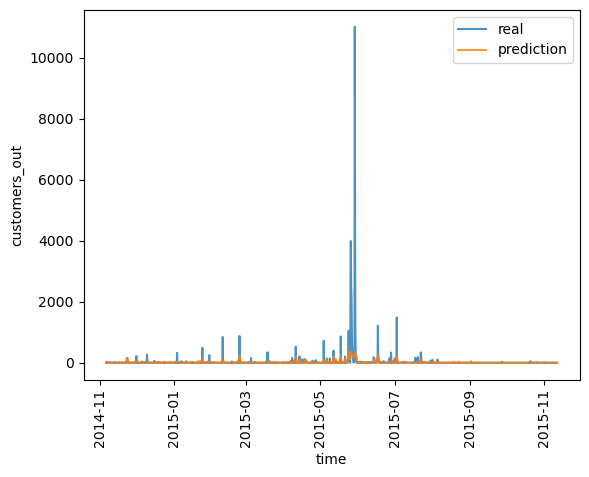

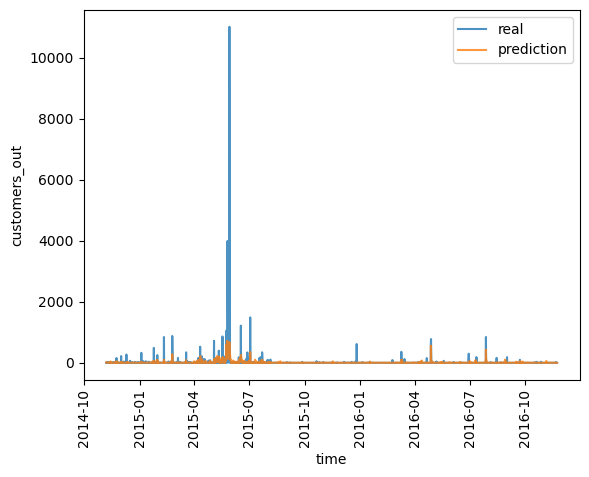

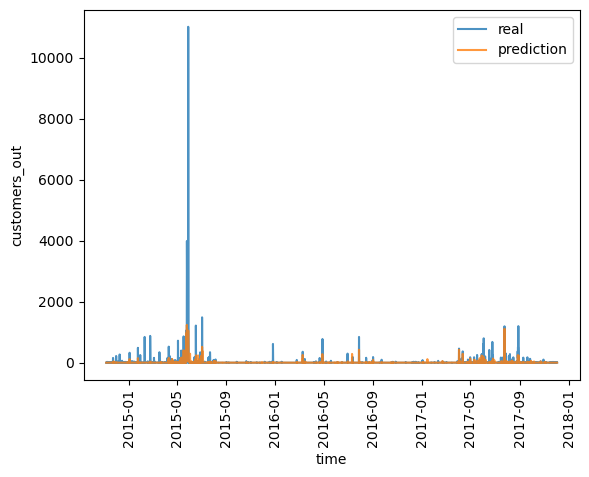

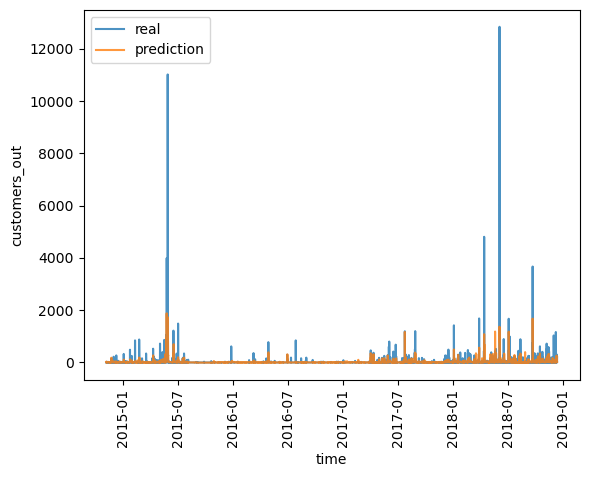

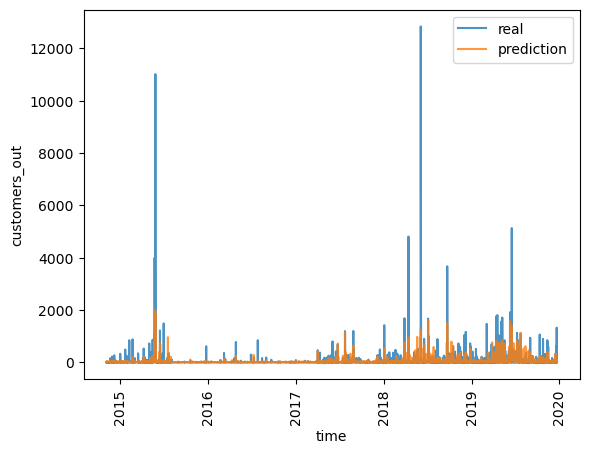

In [18]:
for i , x in enumerate(train_pred):
    fig, ax = plt.subplots()
    l2 = ax.plot(df_county['datetime'].iloc[time_indices[i][0][WINDOW_SIZE:]],df_county[target].iloc[time_indices[i][0][WINDOW_SIZE:]], label = 'real', alpha = 0.8)
    l1 = ax.plot(df_county['datetime'].iloc[time_indices[i][0][WINDOW_SIZE:]],x[:,0],label = 'prediction',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)
    plt.xticks(rotation=90)
    plt.show()

In [19]:
metrics

[{'loss': 115615.5, 'root_mean_squared_error': 340.0227966308594},
 {'loss': 55174.0546875, 'root_mean_squared_error': 234.89158630371094},
 {'loss': 34041.95703125, 'root_mean_squared_error': 184.50462341308594},
 {'loss': 64476.85546875, 'root_mean_squared_error': 253.9229278564453},
 {'loss': 61727.8515625, 'root_mean_squared_error': 248.45089721679688}]

## Predictions on test data

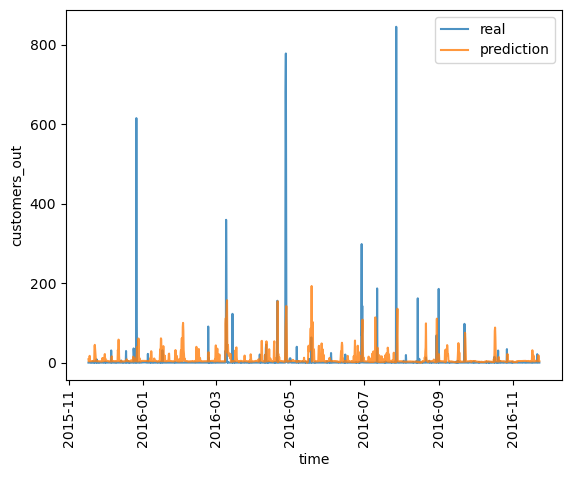

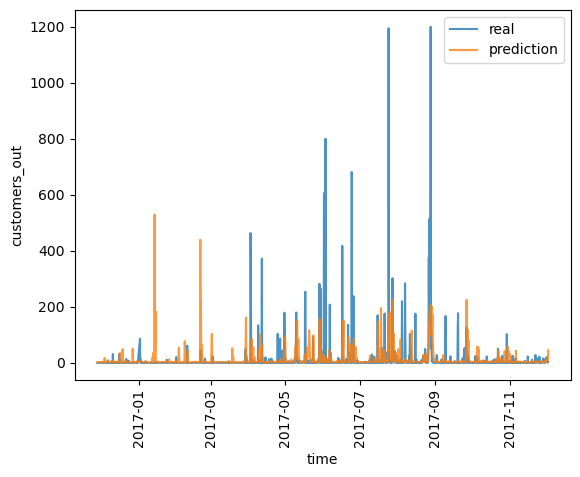

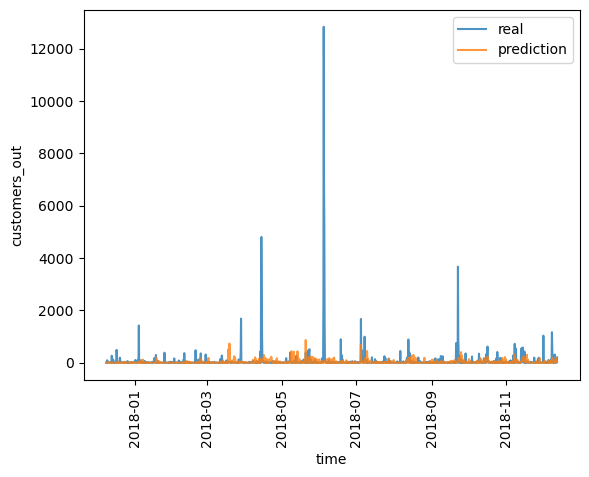

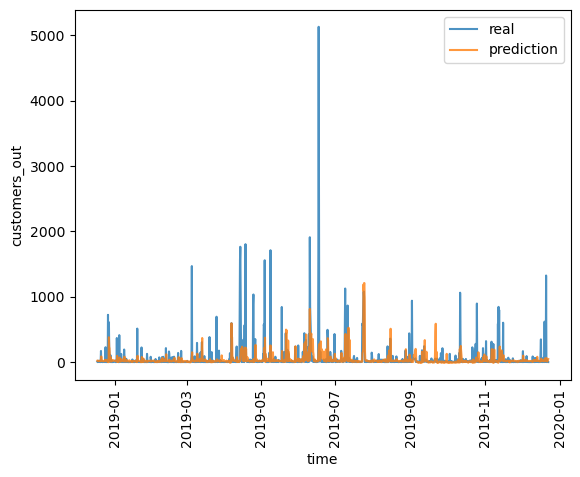

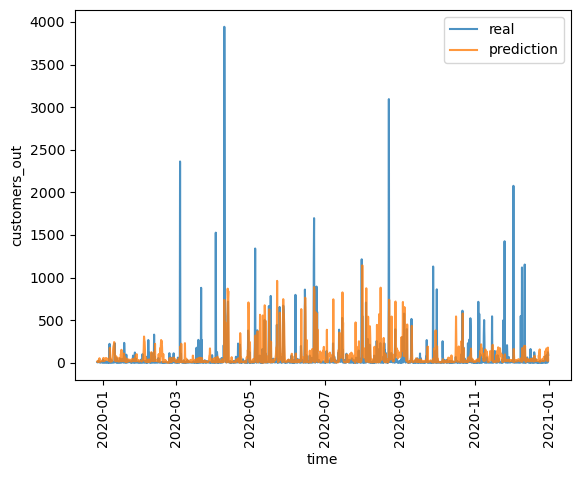

In [20]:
for i , x in enumerate(test_pred):
    fig, ax = plt.subplots()
    l2 = ax.plot(df_county['datetime'].iloc[time_indices[i][1][WINDOW_SIZE:]],df_county[target].iloc[time_indices[i][1][WINDOW_SIZE:]], label = 'real', alpha = 0.8)
    l1 = ax.plot(df_county['datetime'].iloc[time_indices[i][1][WINDOW_SIZE:]],x[:,0],label = 'prediction',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)
    plt.xticks(rotation=90)
    plt.show()

In [21]:
print('MSE for test predictions')
for i , x in enumerate(test_pred):
    print(f'Split {i+1}: {mse(x[:,0],df_county['customers_out'].iloc[time_indices[i][1][WINDOW_SIZE:]])}')

MSE for test predictions
Split 1: 1861.0620222739312
Split 2: 4442.862332691894
Split 3: 225888.1248482661
Split 4: 50029.58503852521
Split 5: 50071.92955394492


Add max of next 4 time entries.

Natural breaks to determine major/medium/minor outage.